# 🔧 Predictive Maintenance System for Industrial Machines

> **Goal:** Predict machine failures before they happen using sensor data and ML classification models.
>
> **Dataset:** AI4I 2020 Predictive Maintenance Dataset (10,000 samples, 14 features)
>
> **Models:** Logistic Regression · Decision Tree · Random Forest · KNN · SVM

## 1. 📦 Import Required Libraries

Importing all necessary libraries for data processing, visualization, ML modelling, and evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

## 2. 📂 Load Dataset

Loading the AI4I 2020 Predictive Maintenance dataset.

In [2]:
dataset=pd.read_csv("ai4i2020.csv")

In [3]:
dataset.head(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. 🔍 Exploratory Data Analysis (EDA)

Understanding the dataset structure, data types, missing values, duplicates, and target class distribution.

In [4]:
dataset.shape

(10000, 14)

In [5]:
dataset.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [6]:
dataset.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [8]:
dataset.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [9]:
dataset.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [10]:
dataset.duplicated().sum()

np.int64(0)

In [11]:
dataset.nunique()

UDI                        10000
Product ID                 10000
Type                           3
Air temperature [K]           93
Process temperature [K]       82
Rotational speed [rpm]       941
Torque [Nm]                  577
Tool wear [min]              246
Machine failure                2
TWF                            2
HDF                            2
PWF                            2
OSF                            2
RNF                            2
dtype: int64

In [12]:
dataset["Type"].unique()

array(['M', 'L', 'H'], dtype=object)

In [13]:
dataset["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

## 4. 🧹 Data Cleaning & Preprocessing

Removing duplicates and dropping irrelevant columns (`UDI`, `Product ID`) and individual failure mode columns (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) to focus on the overall `Machine failure` target.

In [14]:
dataset.drop_duplicates(inplace=True)

In [15]:
dataset.drop(columns=["UDI","Product ID","TWF","HDF","PWF","OSF","RNF"],inplace=True)

In [16]:
dataset.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


## 5. 📊 Data Visualization

Visual exploration of feature distributions, boxplots, correlation heatmap, and pairplot to understand relationships and spot patterns.

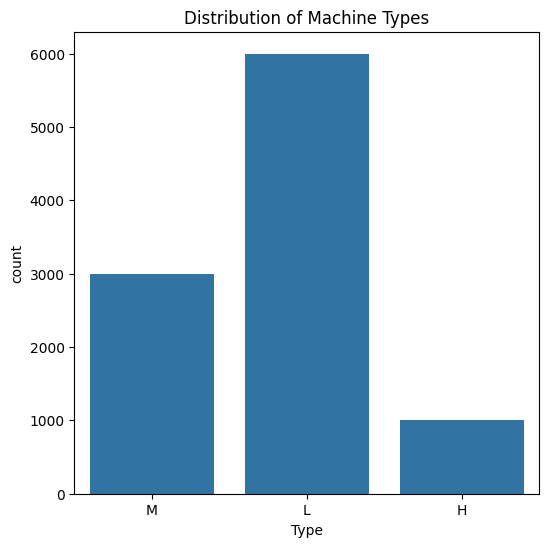

In [17]:
plt.figure(figsize=(6,6))
sns.countplot(data=dataset,x="Type")
plt.title("Distribution of Machine Types")
plt.show()

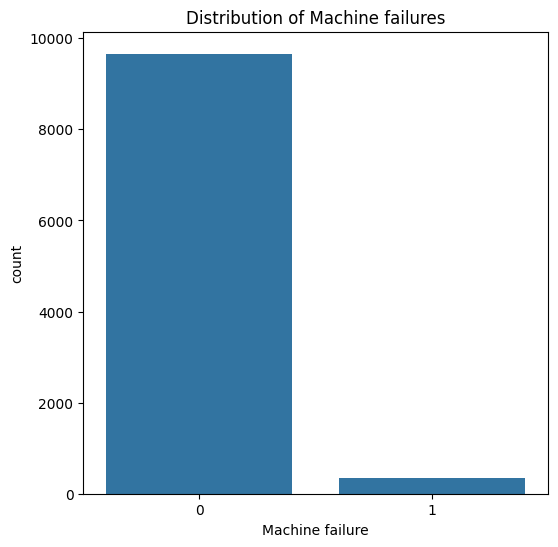

In [18]:
plt.figure(figsize=(6,6))
sns.countplot(data=dataset,x="Machine failure")
plt.title("Distribution of Machine failures")
plt.show()

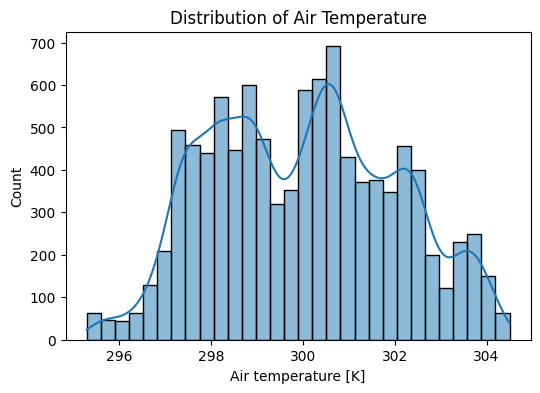

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(dataset["Air temperature [K]"], bins=30, kde=True)
plt.title("Distribution of Air Temperature")
plt.show()

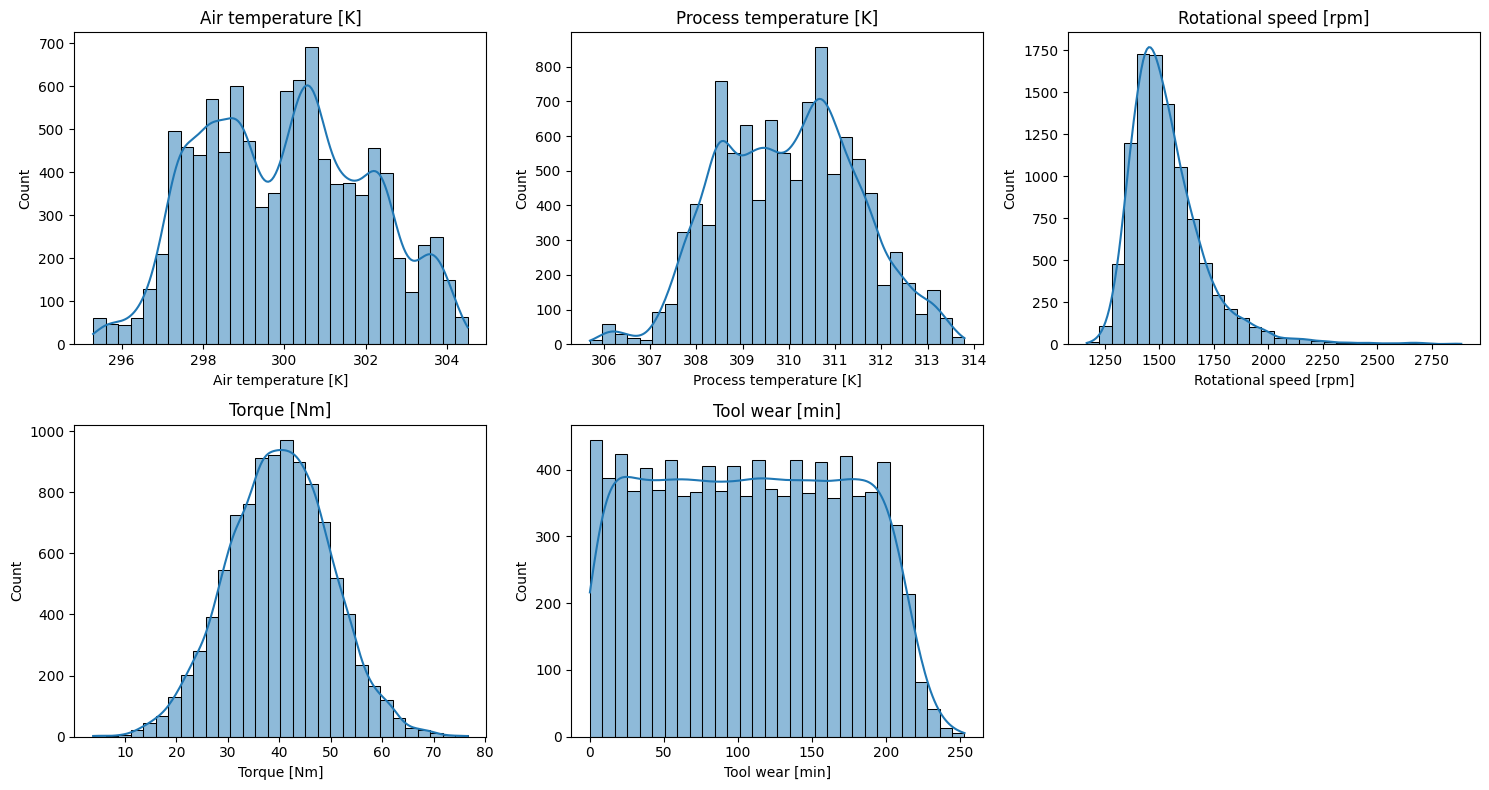

In [20]:
num_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(dataset[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)

# Hide the extra subplot (6th)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

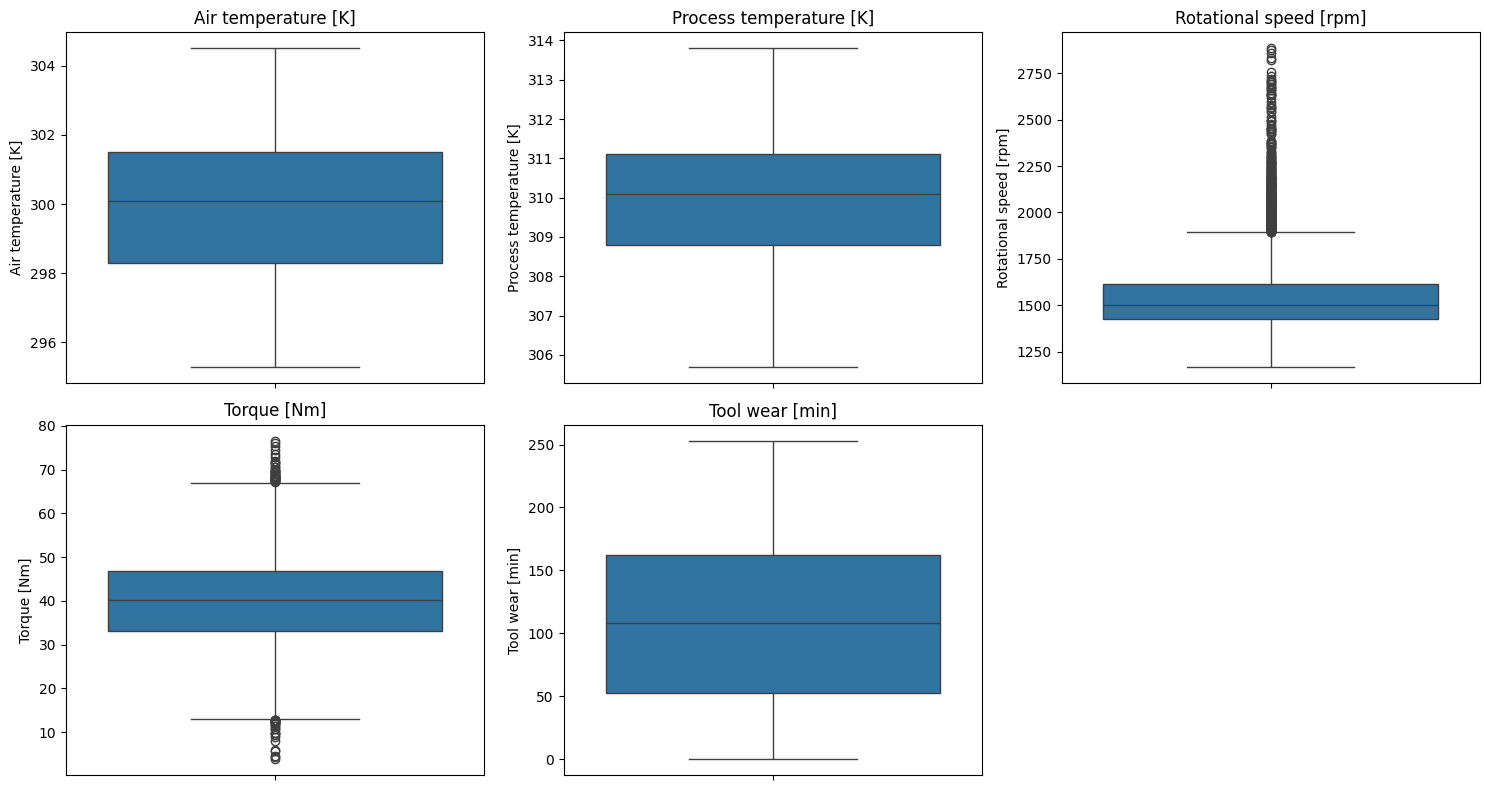

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=dataset[col], ax=axes[i])
    axes[i].set_title(col)

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

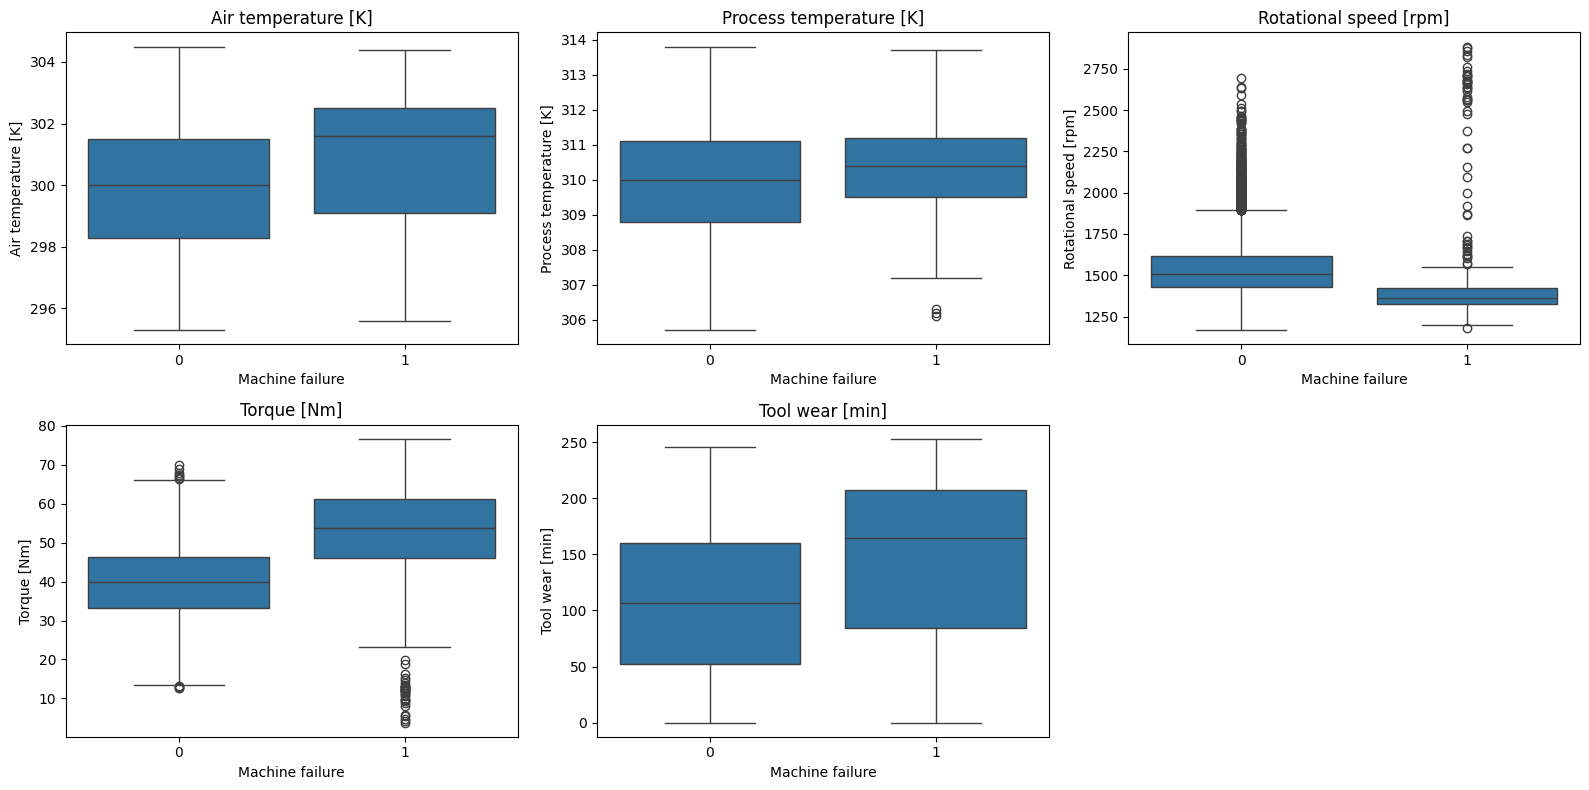

In [22]:
num_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=dataset,
        x="Machine failure",
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(col)

# Remove empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

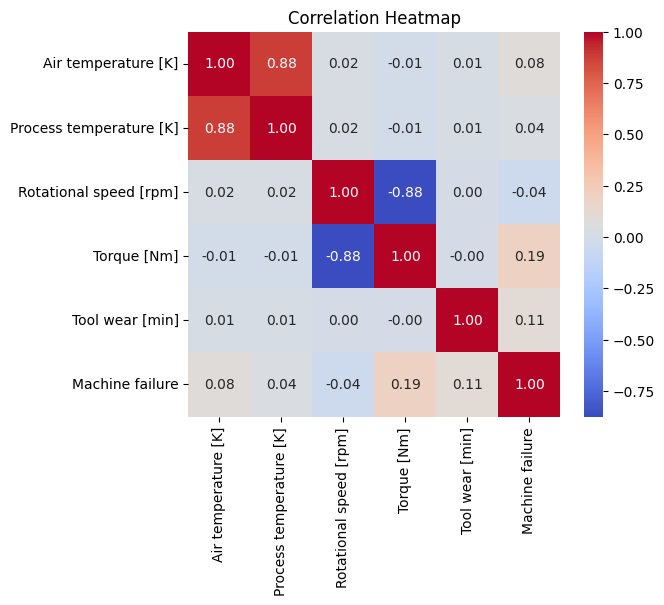

In [23]:
plt.figure(figsize=(6,5))
sns.heatmap(dataset.corr(numeric_only=True),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

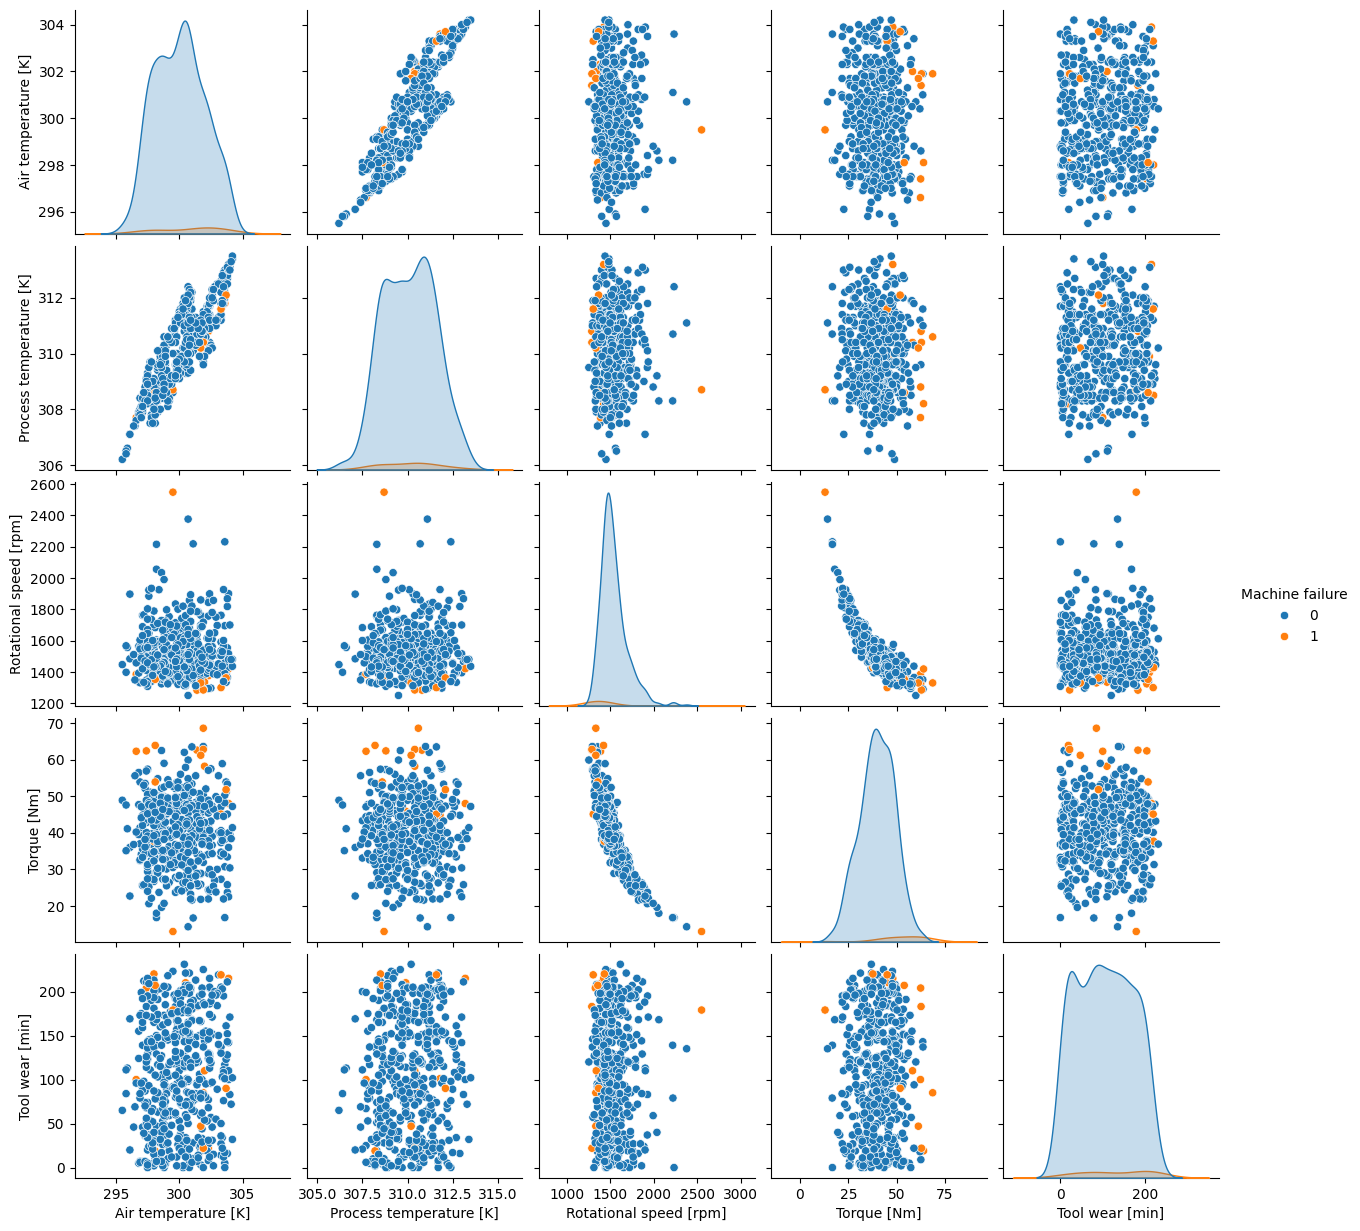

In [24]:
sample_df = dataset.sample(500, random_state=42)

sns.pairplot(
    sample_df,
    vars=[
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]"
    ],
    hue="Machine failure"
)

plt.show()

## 6. ⚙️ Feature Engineering (Encoding Categorical Variables)

Separating features and target, then one-hot encoding the `Type` column (L/M/H machine types).

In [25]:
X=dataset.drop("Machine failure",axis=1)
y=dataset["Machine failure"]

In [26]:
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (10000, 6)
Target Shape : (10000,)


In [27]:
X = pd.get_dummies(
    X,
    columns=["Type"],
    drop_first=True
)

In [28]:
X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,298.1,308.6,1551,42.8,0,False,True
1,298.2,308.7,1408,46.3,3,True,False
2,298.1,308.5,1498,49.4,5,True,False
3,298.2,308.6,1433,39.5,7,True,False
4,298.2,308.7,1408,40.0,9,True,False


## 7. ✂️ Train-Test Split

Splitting data into **80% training** and **20% testing** sets with stratification to preserve class ratio.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (8000, 7)
X_test : (2000, 7)
y_train : (8000,)
y_test : (2000,)


## 8. 📐 Feature Scaling

Applying `StandardScaler` to normalize features — essential for distance-based models (KNN, SVM) and Logistic Regression.

In [31]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
print(y_train.value_counts())

Machine failure
0    7729
1     271
Name: count, dtype: int64


## 9. ⚖️ Handling Class Imbalance (SMOTE)

The dataset is heavily imbalanced (~3% failures). Applying **SMOTE** (Synthetic Minority Over-sampling Technique) on training data to balance classes.

In [33]:
smote=SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

In [34]:
print(y_train.value_counts())

Machine failure
0    7729
1    7729
Name: count, dtype: int64


## 10. 🤖 Model Training

Training five classification models on the SMOTE-balanced training data.

### 10.1 — Logistic Regression

In [35]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train, y_train)
print("Logistic Regression trained successfully!")

lr_pred = lr.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

Logistic Regression trained successfully!
Logistic Regression Accuracy: 0.8295


### 10.2 — Decision Tree

In [36]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)
print("Decision Tree trained successfully!")

dt_pred = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

Decision Tree trained successfully!
Decision Tree Accuracy: 0.9570


### 10.3 — Random Forest

In [37]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)
print("Random Forest trained successfully!")

rf_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest trained successfully!
Random Forest Accuracy: 0.9660


### 10.4 — K-Nearest Neighbors (KNN)

In [38]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)
print("KNN trained successfully!")

knn_pred = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)
print(f"KNN Accuracy: {knn_accuracy:.4f}")

KNN trained successfully!
KNN Accuracy: 0.9300


### 10.5 — Support Vector Machine (SVM)

In [39]:
svm = SVC(
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)
print("SVM trained successfully!")

svm_pred = svm.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)
print(f"SVM Accuracy: {svm_accuracy:.4f}")

SVM trained successfully!
SVM Accuracy: 0.9185


## 11. 📋 Model Accuracy Summary

Quick accuracy comparison across all five trained models.

In [40]:
accuracy_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM"

    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        svm_accuracy

    ]
})

accuracy_results.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

accuracy_results.reset_index(drop=True, inplace=True)

accuracy_results

,Model,Accuracy
0,Random Forest,0.9660
1,Decision Tree,0.9570
2,KNN,0.9300
3,SVM,0.9185
4,Logistic Regression,0.8295


## 12. 📈 Detailed Model Evaluation

Per-model breakdown: Accuracy, Precision, Recall, F1 Score, ROC-AUC, Confusion Matrix, and ROC Curve.

### 12.1 — Logistic Regression Evaluation

In [41]:
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

In [42]:
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC AUC  :", roc_auc_score(y_test, lr_prob))

Accuracy : 0.8295
Precision: 0.14545454545454545
Recall   : 0.8235294117647058
F1 Score : 0.24724061810154527
ROC AUC  : 0.9078294361222751


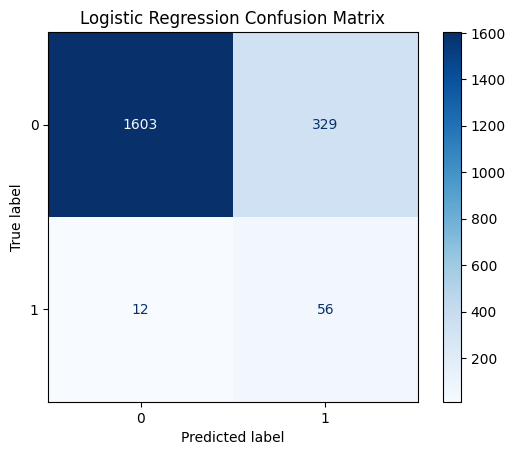

In [43]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [44]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1932
           1       0.15      0.82      0.25        68

    accuracy                           0.83      2000
   macro avg       0.57      0.83      0.58      2000
weighted avg       0.96      0.83      0.88      2000



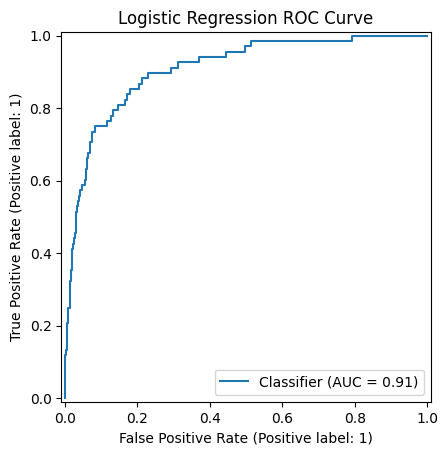

In [45]:
RocCurveDisplay.from_predictions(
    y_test,
    lr_prob
)

plt.title("Logistic Regression ROC Curve")
plt.show()

### 12.2 — Decision Tree Evaluation

In [46]:
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:,1]

In [47]:
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))
print("ROC AUC  :", roc_auc_score(y_test, dt_prob))

Accuracy : 0.957
Precision: 0.425
Recall   : 0.75
F1 Score : 0.5425531914893617
ROC AUC  : 0.8571428571428571


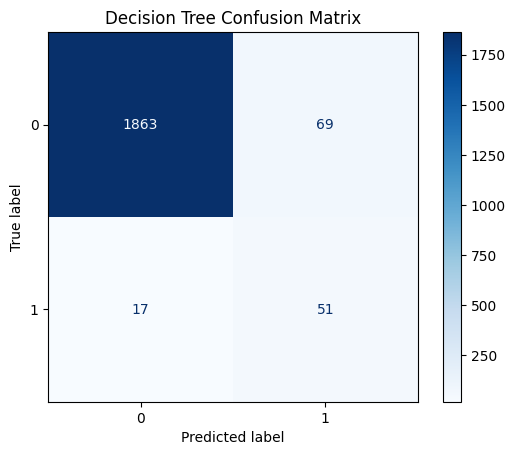

In [48]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [49]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1932
           1       0.42      0.75      0.54        68

    accuracy                           0.96      2000
   macro avg       0.71      0.86      0.76      2000
weighted avg       0.97      0.96      0.96      2000



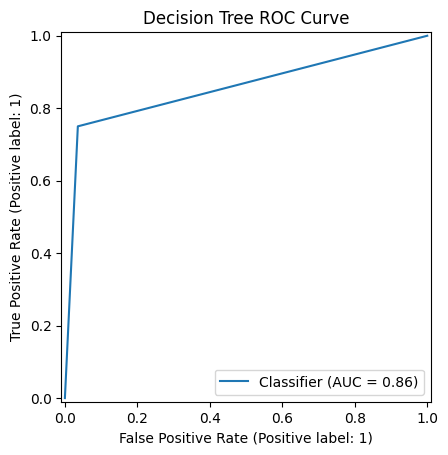

In [50]:
RocCurveDisplay.from_predictions(
    y_test,
    dt_prob
)

plt.title("Decision Tree ROC Curve")
plt.show()

### 12.3 — Random Forest Evaluation

Accuracy : 0.966
Precision: 0.5
Recall   : 0.7647058823529411
F1 Score : 0.6046511627906976
ROC AUC  : 0.9679850200949945


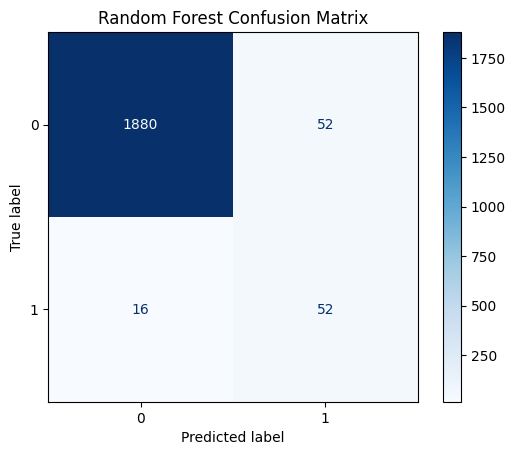

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.50      0.76      0.60        68

    accuracy                           0.97      2000
   macro avg       0.75      0.87      0.79      2000
weighted avg       0.97      0.97      0.97      2000



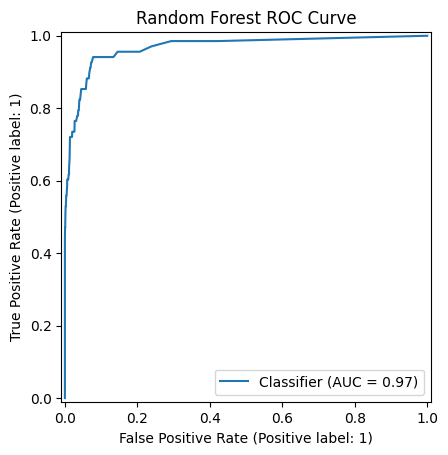

In [51]:
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf_prob))

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

print(classification_report(y_test, rf_pred))

RocCurveDisplay.from_predictions(y_test, rf_prob)
plt.title("Random Forest ROC Curve")
plt.show()

### 12.4 — KNN Evaluation

Accuracy : 0.93
Precision: 0.3
Recall   : 0.7941176470588235
F1 Score : 0.43548387096774194
ROC AUC  : 0.8965221958348557


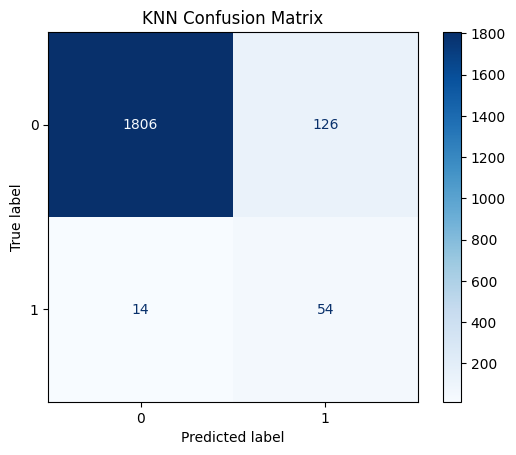

              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1932
           1       0.30      0.79      0.44        68

    accuracy                           0.93      2000
   macro avg       0.65      0.86      0.70      2000
weighted avg       0.97      0.93      0.94      2000



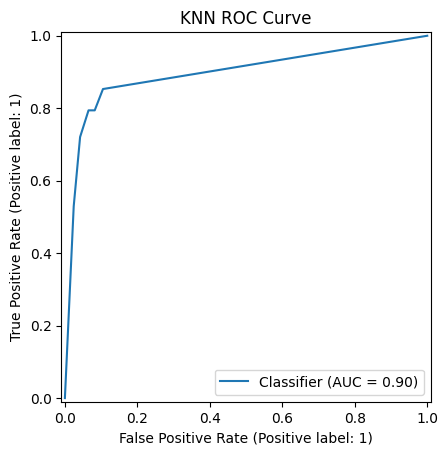

In [52]:
knn_pred = knn.predict(X_test)
knn_prob = knn.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred))
print("Recall   :", recall_score(y_test, knn_pred))
print("F1 Score :", f1_score(y_test, knn_pred))
print("ROC AUC  :", roc_auc_score(y_test, knn_prob))

ConfusionMatrixDisplay.from_predictions(y_test, knn_pred, cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.show()

print(classification_report(y_test, knn_pred))

RocCurveDisplay.from_predictions(y_test, knn_prob)
plt.title("KNN ROC Curve")
plt.show()

### 12.5 — SVM Evaluation

Accuracy : 0.9185
Precision: 0.28110599078341014
Recall   : 0.8970588235294118
F1 Score : 0.4280701754385965
ROC AUC  : 0.9599926927292657


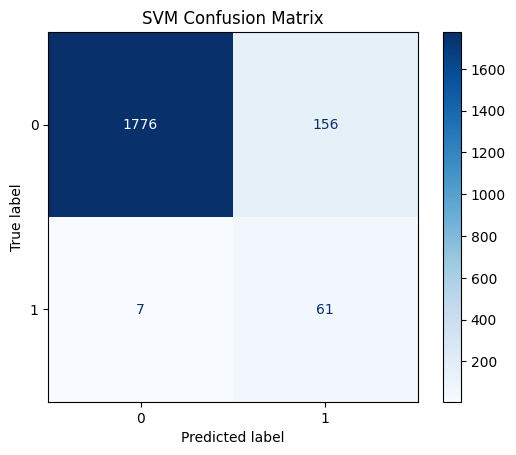

              precision    recall  f1-score   support

           0       1.00      0.92      0.96      1932
           1       0.28      0.90      0.43        68

    accuracy                           0.92      2000
   macro avg       0.64      0.91      0.69      2000
weighted avg       0.97      0.92      0.94      2000



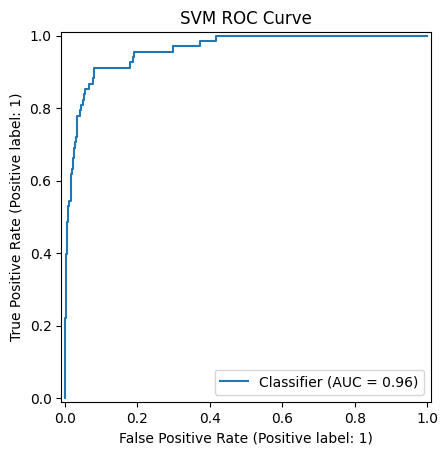

In [53]:
svm_pred = svm.predict(X_test)
svm_prob = svm.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall   :", recall_score(y_test, svm_pred))
print("F1 Score :", f1_score(y_test, svm_pred))
print("ROC AUC  :", roc_auc_score(y_test, svm_prob))

ConfusionMatrixDisplay.from_predictions(y_test, svm_pred, cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.show()

print(classification_report(y_test, svm_pred))

RocCurveDisplay.from_predictions(y_test, svm_prob)
plt.title("SVM ROC Curve")
plt.show()

## 13. 🏆 Model Comparison Table

Comprehensive comparison table of all models across every evaluation metric, with best values highlighted in green.

In [54]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, svm_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, svm_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, svm_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, knn_prob),
        roc_auc_score(y_test, svm_prob)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8295,0.145455,0.823529,0.247241,0.907829
1,Decision Tree,0.9570,0.425000,0.750000,0.542553,0.857143
2,Random Forest,0.9660,0.500000,0.764706,0.604651,0.967985
3,KNN,0.9300,0.300000,0.794118,0.435484,0.896522
4,SVM,0.9185,0.281106,0.897059,0.428070,0.959993


In [55]:
comparison = comparison.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.9660,0.500000,0.764706,0.604651,0.967985
1,Decision Tree,0.9570,0.425000,0.750000,0.542553,0.857143
2,KNN,0.9300,0.300000,0.794118,0.435484,0.896522
3,SVM,0.9185,0.281106,0.897059,0.428070,0.959993
4,Logistic Regression,0.8295,0.145455,0.823529,0.247241,0.907829


In [56]:
comparison.style.highlight_max(
    color="lightgreen",
    subset=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.966000,0.500000,0.764706,0.604651,0.967985
1,Decision Tree,0.957000,0.425000,0.750000,0.542553,0.857143
2,KNN,0.930000,0.300000,0.794118,0.435484,0.896522
3,SVM,0.918500,0.281106,0.897059,0.428070,0.959993
4,Logistic Regression,0.829500,0.145455,0.823529,0.247241,0.907829


## 14. 📉 Comparison Visualizations

Bar charts comparing Accuracy, F1 Score, and Recall across all models.

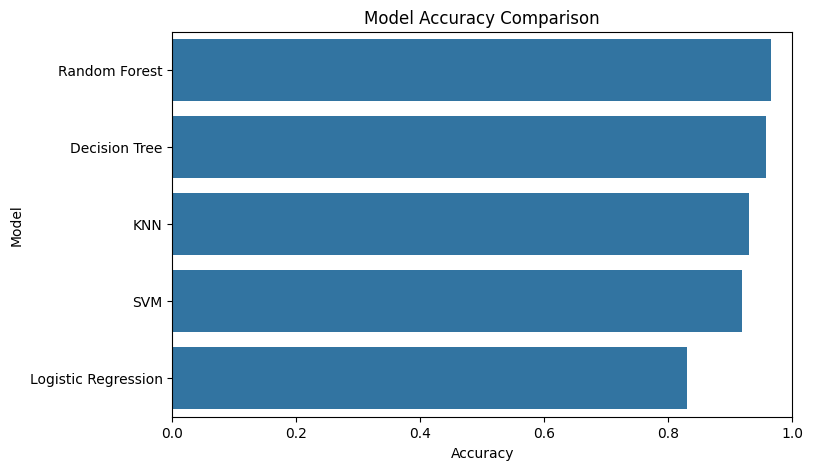

In [57]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Accuracy",
    y="Model"
)

plt.title("Model Accuracy Comparison")
plt.xlim(0,1)
plt.show()

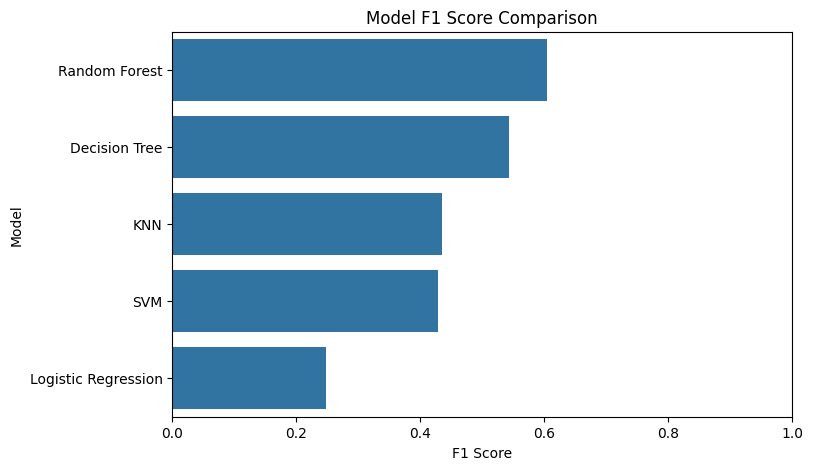

In [58]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="F1 Score",
    y="Model"
)

plt.title("Model F1 Score Comparison")
plt.xlim(0,1)
plt.show()

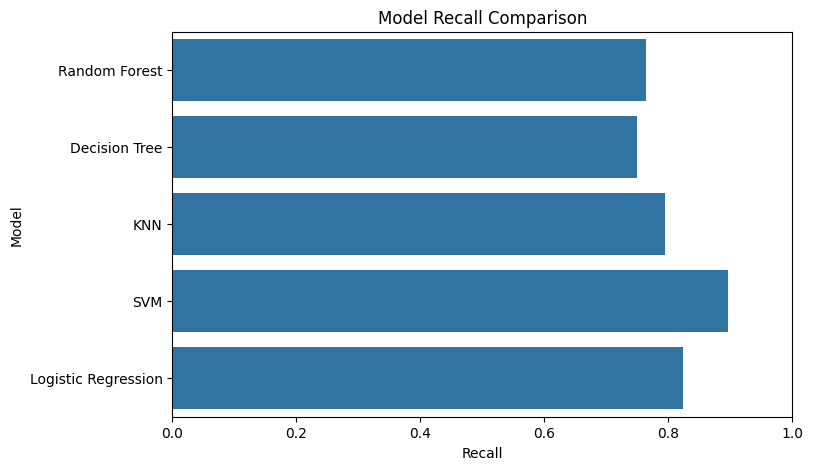

In [59]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Recall",
    y="Model"
)

plt.title("Model Recall Comparison")
plt.xlim(0,1)
plt.show()

## 15. 🔎 Hyperparameter Tuning — GridSearchCV (Random Forest)

Exhaustive grid search over key Random Forest hyperparameters using 4-fold cross-validation, optimizing for **F1 Score**.

In [ ]:
# Optimized Parameter Grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    param_grid=param_grid,
    scoring="f1",
    cv=4,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1 Score:")
print(grid_search.best_score_)

best_rf = grid_search.best_estimator_

best_pred = best_rf.predict(X_test)
best_prob = best_rf.predict_proba(X_test)[:, 1]

print("\nModel Performance After GridSearchCV")
print("Accuracy :", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred))
print("Recall   :", recall_score(y_test, best_pred))
print("F1 Score :", f1_score(y_test, best_pred))
print("ROC AUC  :", roc_auc_score(y_test, best_prob))

Fitting 4 folds for each of 24 candidates, totalling 96 fits


## 16. 🎲 Hyperparameter Tuning — RandomizedSearchCV (Random Forest)

Faster randomized search over the same hyperparameter space — useful when the search grid is large.

In [ ]:
# Parameter Distribution
param_dist = {
    "n_estimators": [100, 150],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=5,
    scoring="f1",
    cv=4,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Train on SMOTE Balanced Training Data
random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(random_search.best_score_)

best_rf = random_search.best_estimator_

best_pred = best_rf.predict(X_test)
best_prob = best_rf.predict_proba(X_test)[:, 1]

print("\nModel Performance After RandomizedSearchCV")
print("Accuracy :", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred))
print("Recall   :", recall_score(y_test, best_pred))
print("F1 Score :", f1_score(y_test, best_pred))
print("ROC AUC  :", roc_auc_score(y_test, best_prob))